In [5]:
import pandas as pd
import json
import re
from pathlib import Path
from collections import Counter

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# Define the folder containing the raw Adzuna JSON files
DATA_DIR = Path("../data/raw/adzuna")

# Raw job-posting files collected for the project
files = [
    "adzuna_software_engineer_2026-09-29.json",
    "adzuna_business_analyst_2026-09-29.json",
    "adzuna_data_analyst_2026-09-29.json",
    "adzuna_digital_marketing_2026-09-29.json"
]

print("Data directory:", DATA_DIR)
print("Files to load:")
for file in files:
    print("-", file)

Data directory: ../data/raw/adzuna
Files to load:
- adzuna_software_engineer_2026-09-29.json
- adzuna_business_analyst_2026-09-29.json
- adzuna_data_analyst_2026-09-29.json
- adzuna_digital_marketing_2026-09-29.json


In [7]:
# Load all job postings from the raw JSON files

all_jobs = []

for file in files:
    file_path = DATA_DIR / file
    
    with open(file_path, "r", encoding="utf-8") as f:
        jobs = json.load(f)
    
    print(f"{file}: {len(jobs)} records")
    all_jobs.extend(jobs)

print("\nTotal job postings loaded:", len(all_jobs))

adzuna_software_engineer_2026-09-29.json: 625 records
adzuna_business_analyst_2026-09-29.json: 625 records
adzuna_data_analyst_2026-09-29.json: 625 records
adzuna_digital_marketing_2026-09-29.json: 625 records

Total job postings loaded: 2500


In [8]:
# Convert the combined job postings into a DataFrame
df = pd.DataFrame(all_jobs)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (2500, 17)

Columns:
['redirect_url', 'description', 'created', 'contract_time', 'adref', 'id', 'location', 'company', 'longitude', 'latitude', '__CLASS__', 'category', 'salary_is_predicted', 'title', 'contract_type', 'salary_max', 'salary_min']


In [9]:
# Inspect the fields relevant to text analysis

print("Description data type:")
print(df["description"].map(type).value_counts())

print("\nMissing values:")
print(df[["id", "title", "description", "category"]].isnull().sum())

print("\nSample job description:")
print(df["description"].iloc[0][:1000])

Description data type:
description
<class 'str'>    2500
Name: count, dtype: int64

Missing values:
id             0
title          0
description    0
category       0
dtype: int64

Sample job description:
This job is with ABB, an inclusive employer and a member of myGwork – the largest global platform for the LGBTQ business community. Please do not contact the recruiter directly. At ABB, we help industries run leaner and cleaner—and every person here makes that happen. You’ll be empowered to lead, supported to grow, and proud of the impact we create together. Join us and help run what runs the world. This Position reports to: Digital Solution Engineering Manager What we believe in ABB’s Process …


In [10]:
# Extract fields required for text cleaning and EDA

text_df = df[["id", "title", "category", "description"]].copy()

# Extract the category label from the nested category field
text_df["category_name"] = text_df["category"].apply(
    lambda x: x.get("label") if isinstance(x, dict) else None
)

# Rename the job identifier for clarity
text_df.rename(columns={"id": "job_id"}, inplace=True)

# Keep only the fields needed for the text-data track
text_df = text_df[
    ["job_id", "title", "category_name", "description"]
]

print("Text dataset shape:", text_df.shape)
print("\nColumns:")
print(text_df.columns.tolist())

print("\nJob categories:")
print(text_df["category_name"].value_counts())

Text dataset shape: (2500, 4)

Columns:
['job_id', 'title', 'category_name', 'description']

Job categories:
category_name
IT Jobs                             1713
PR, Advertising & Marketing Jobs     494
Accounting & Finance Jobs             72
Sales Jobs                            70
Engineering Jobs                      43
Creative & Design Jobs                37
Consultancy Jobs                      16
HR & Recruitment Jobs                 12
Teaching Jobs                         10
Admin Jobs                             9
Energy, Oil & Gas Jobs                 7
Scientific & QA Jobs                   5
Logistics & Warehouse Jobs             3
Trade & Construction Jobs              2
Legal Jobs                             2
Graduate Jobs                          2
Manufacturing Jobs                     1
Healthcare & Nursing Jobs              1
Customer Services Jobs                 1
Name: count, dtype: int64


In [11]:
# Preserve the original job description before preprocessing

text_df["description_original"] = text_df["description"]

# Create a separate working column for text preprocessing
text_df["description_clean"] = text_df["description"]

print("Original description preserved:", 
      text_df["description_original"].notna().all())

print("Clean description column created:", 
      "description_clean" in text_df.columns)

print("\nCurrent shape:", text_df.shape)

Original description preserved: True
Clean description column created: True

Current shape: (2500, 6)


In [12]:
# Check for HTML tags in job descriptions

html_pattern = r"<[^>]+>"

html_count = text_df["description_clean"].str.contains(
    html_pattern,
    regex=True,
    na=False
).sum()

print("Descriptions containing HTML tags:", html_count)
print("Total descriptions:", len(text_df))
print("Percentage containing HTML: {:.2f}%".format(
    html_count / len(text_df) * 100
))

Descriptions containing HTML tags: 0
Total descriptions: 2500
Percentage containing HTML: 0.00%


In [13]:
# Normalize job description text
# Technical symbols are preserved because they may represent skills.

text_df["description_clean"] = (
    text_df["description_clean"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("Text normalization completed.")

print("\nOriginal description:")
print(text_df["description_original"].iloc[0][:500])

print("\nCleaned description:")
print(text_df["description_clean"].iloc[0][:500])

Text normalization completed.

Original description:
This job is with ABB, an inclusive employer and a member of myGwork – the largest global platform for the LGBTQ business community. Please do not contact the recruiter directly. At ABB, we help industries run leaner and cleaner—and every person here makes that happen. You’ll be empowered to lead, supported to grow, and proud of the impact we create together. Join us and help run what runs the world. This Position reports to: Digital Solution Engineering Manager What we believe in ABB’s Process …

Cleaned description:
this job is with abb, an inclusive employer and a member of mygwork – the largest global platform for the lgbtq business community. please do not contact the recruiter directly. at abb, we help industries run leaner and cleaner—and every person here makes that happen. you’ll be empowered to lead, supported to grow, and proud of the impact we create together. join us and help run what runs the world. this position reports

In [14]:
# Validate the text normalization

print("Original and cleaned descriptions stored separately:",
      "description_original" in text_df.columns and
      "description_clean" in text_df.columns)

print("All cleaned descriptions are lowercase:",
      text_df["description_clean"].str.islower().all())

print("Missing cleaned descriptions:",
      text_df["description_clean"].isna().sum())

# Check whether multiple consecutive spaces remain
multiple_spaces = text_df["description_clean"].str.contains(
    r"\s{2,}", regex=True, na=False
).sum()

print("Descriptions with multiple consecutive spaces:", multiple_spaces)

Original and cleaned descriptions stored separately: True
All cleaned descriptions are lowercase: False
Missing cleaned descriptions: 0
Descriptions with multiple consecutive spaces: 0


In [15]:
# Check whether alphabetic characters in the cleaned text are lowercase

def check_lowercase(text):
    letters = [char for char in text if char.isalpha()]
    return all(char.islower() for char in letters)

lowercase_check = text_df["description_clean"].apply(check_lowercase)

print("Descriptions with all alphabetic characters lowercase:",
      lowercase_check.sum())

print("Descriptions not fully lowercase:",
      (~lowercase_check).sum())

Descriptions with all alphabetic characters lowercase: 2498
Descriptions not fully lowercase: 2


In [16]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print("Number of English stopwords:", len(stop_words))
print("Sample stopwords:", list(stop_words)[:20])

Number of English stopwords: 198
Sample stopwords: ['aren', "doesn't", "mustn't", 'which', 'off', 'too', 'doing', 'be', 'them', 'whom', 't', 'while', 'me', "hadn't", 'until', 'than', 'y', 'a', 'she', 'those']


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mithresh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
# Inspect the effect of stopword removal on a sample description

sample_text = text_df["description_clean"].iloc[0]

sample_words = sample_text.split()

filtered_words = [
    word for word in sample_words
    if word not in stop_words
]

print("Original word count:", len(sample_words))
print("After stopword removal:", len(filtered_words))
print("Words removed:", len(sample_words) - len(filtered_words))

print("\nBefore:")
print(" ".join(sample_words[:50]))

print("\nAfter:")
print(" ".join(filtered_words[:50]))

Original word count: 85
After stopword removal: 53
Words removed: 32

Before:
this job is with abb, an inclusive employer and a member of mygwork – the largest global platform for the lgbtq business community. please do not contact the recruiter directly. at abb, we help industries run leaner and cleaner—and every person here makes that happen. you’ll be empowered to lead,

After:
job abb, inclusive employer member mygwork – largest global platform lgbtq business community. please contact recruiter directly. abb, help industries run leaner cleaner—and every person makes happen. you’ll empowered lead, supported grow, proud impact create together. join us help run runs world. position reports to: digital solution engineering manager believe


In [18]:
# Preserve important negation words during stopword removal

protected_words = {
    "no", "not", "nor", "never",
    "neither", "without"
}

custom_stop_words = stop_words - protected_words

print("Original stopwords:", len(stop_words))
print("Protected words:", sorted(protected_words))
print("Stopwords used for removal:", len(custom_stop_words))

Original stopwords: 198
Protected words: ['neither', 'never', 'no', 'nor', 'not', 'without']
Stopwords used for removal: 195


In [19]:
# Remove stopwords while preserving the normalized text column

def remove_stopwords(text):
    words = text.split()
    return " ".join(
        word for word in words
        if word not in custom_stop_words
    )

text_df["description_nostopwords"] = (
    text_df["description_clean"].apply(remove_stopwords)
)

print("Stopword removal completed.")

print("\nColumns:")
print(text_df.columns.tolist())

Stopword removal completed.

Columns:
['job_id', 'title', 'category_name', 'description', 'description_original', 'description_clean', 'description_nostopwords']


In [20]:
# Validate the stopword removal

sample_original = text_df["description_clean"].iloc[0]
sample_nostop = text_df["description_nostopwords"].iloc[0]

print("Original normalized text:")
print(sample_original[:500])

print("\nText after stopword removal:")
print(sample_nostop[:500])

print("\nProtected-word check:")
for word in sorted(protected_words):
    if word in sample_original.split():
        print(f"{word}:",
              "preserved" if word in sample_nostop.split() else "REMOVED")

Original normalized text:
this job is with abb, an inclusive employer and a member of mygwork – the largest global platform for the lgbtq business community. please do not contact the recruiter directly. at abb, we help industries run leaner and cleaner—and every person here makes that happen. you’ll be empowered to lead, supported to grow, and proud of the impact we create together. join us and help run what runs the world. this position reports to: digital solution engineering manager what we believe in abb’s process …

Text after stopword removal:
job abb, inclusive employer member mygwork – largest global platform lgbtq business community. please not contact recruiter directly. abb, help industries run leaner cleaner—and every person makes happen. you’ll empowered lead, supported grow, proud impact create together. join us help run runs world. position reports to: digital solution engineering manager believe abb’s process …

Protected-word check:
not: preserved


In [21]:
import spacy

print("spaCy version:", spacy.__version__)

spaCy version: 3.8.14


In [22]:
# Load the English spaCy model for lemmatization

nlp = spacy.load("en_core_web_sm")

print("English spaCy model loaded successfully.")

English spaCy model loaded successfully.


In [23]:
# Test lemmatization on one job description

sample_text = text_df["description_clean"].iloc[0]

doc = nlp(sample_text)

sample_lemmas = [
    token.lemma_
    for token in doc
    if not token.is_space
]

print("Original text:")
print(sample_text[:500])

print("\nLemmatized text:")
print(" ".join(sample_lemmas[:100]))

Original text:
this job is with abb, an inclusive employer and a member of mygwork – the largest global platform for the lgbtq business community. please do not contact the recruiter directly. at abb, we help industries run leaner and cleaner—and every person here makes that happen. you’ll be empowered to lead, supported to grow, and proud of the impact we create together. join us and help run what runs the world. this position reports to: digital solution engineering manager what we believe in abb’s process …

Lemmatized text:
this job be with abb , an inclusive employer and a member of mygwork – the large global platform for the lgbtq business community . please do not contact the recruiter directly . at abb , we help industry run lean and clean — and every person here make that happen . you ’ll be empower to lead , support to grow , and proud of the impact we create together . join we and help run what run the world . this position report to : digital solution engineering manager wh

In [24]:
# Lemmatize all job descriptions using spaCy

def lemmatize_text(text):
    doc = nlp(text)
    return " ".join(
        token.lemma_
        for token in doc
        if not token.is_space
    )

text_df["description_lemmatized"] = text_df["description_clean"].apply(
    lemmatize_text
)

print("Lemmatization completed.")

print("\nNew columns:")
print(text_df.columns.tolist())

print("\nSample lemmatized description:")
print(text_df["description_lemmatized"].iloc[0][:500])

Lemmatization completed.

New columns:
['job_id', 'title', 'category_name', 'description', 'description_original', 'description_clean', 'description_nostopwords', 'description_lemmatized']

Sample lemmatized description:
this job be with abb , an inclusive employer and a member of mygwork – the large global platform for the lgbtq business community . please do not contact the recruiter directly . at abb , we help industry run lean and clean — and every person here make that happen . you ’ll be empower to lead , support to grow , and proud of the impact we create together . join we and help run what run the world . this position report to : digital solution engineering manager what we believe in abb ’s process …


In [25]:
# Validate the lemmatized text

print("Total records:", len(text_df))

print(
    "Missing lemmatized descriptions:",
    text_df["description_lemmatized"].isna().sum()
)

print(
    "Empty lemmatized descriptions:",
    (
        text_df["description_lemmatized"]
        .fillna("")
        .str.strip()
        .eq("")
        .sum()
    )
)

print(
    "Average original word count:",
    text_df["description_original"].str.split().str.len().mean()
)

print(
    "Average lemmatized word count:",
    text_df["description_lemmatized"].str.split().str.len().mean()
)

Total records: 2500
Missing lemmatized descriptions: 0
Empty lemmatized descriptions: 0
Average original word count: 71.5228
Average lemmatized word count: 85.6052


In [26]:
# Calculate the number of words in each original job description

text_df["description_word_count"] = (
    text_df["description_original"]
    .fillna("")
    .str.split()
    .str.len()
)

print("Description length calculated.")

print("\nSummary statistics:")
print(text_df["description_word_count"].describe())

Description length calculated.

Summary statistics:
count    2500.000000
mean       71.522800
std         8.600271
min        19.000000
25%        68.000000
50%        72.000000
75%        77.000000
max        96.000000
Name: description_word_count, dtype: float64


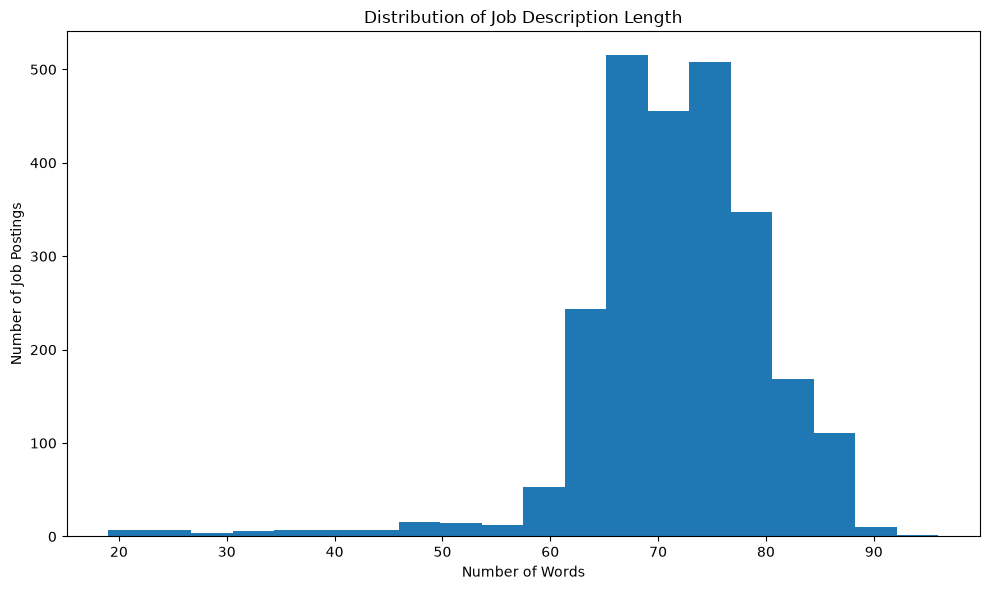

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    text_df["description_word_count"],
    bins=20
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Job Postings")
plt.title("Distribution of Job Description Length")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of job description length is concentrated mainly between 60 and 85 words. The median description length is 72 words, while the mean is approximately 71.52 words. A small number of postings contain substantially shorter descriptions, resulting in a lower tail.

Overall, the dataset contains relatively consistent job description lengths, which provides a reasonably uniform textual basis for subsequent skill-frequency and text-mining analysis.

In [29]:
# Initial skill vocabulary for text-based EDA

skill_keywords = [
    "python",
    "java",
    "javascript",
    "typescript",
    "c++",
    "c#",
    "sql",
    "r",
    "html",
    "css",
    "react",
    "node.js",
    "express",
    "mongodb",
    "mysql",
    "postgresql",
    "aws",
    "azure",
    "gcp",
    "docker",
    "kubernetes",
    "git",
    "github",
    "machine learning",
    "deep learning",
    "data science",
    "data analysis",
    "power bi",
    "tableau",
    "excel",
    "tensorflow",
    "pytorch",
    "spark",
    "hadoop",
    "snowflake",
    "linux"
]

print("Number of skills in initial vocabulary:", len(skill_keywords))

Number of skills in initial vocabulary: 36


In [30]:
# Count recognized skills in a job description

def count_skills(text, skills):
    text = text.lower()
    counts = {}

    for skill in skills:
        if skill in {"c++", "c#", "r"}:
            # Exact word/skill matching for short or symbol-based skills
            pattern = r"(?<!\w)" + re.escape(skill) + r"(?!\w)"
        else:
            # Prevent partial-word matches
            pattern = r"(?<!\w)" + re.escape(skill) + r"(?!\w)"

        counts[skill] = len(re.findall(pattern, text))

    return counts


# Test on the first job description
sample_skill_counts = count_skills(
    text_df["description_clean"].iloc[0],
    skill_keywords
)

sample_skill_counts = {
    skill: count
    for skill, count in sample_skill_counts.items()
    if count > 0
}

print("Skills detected in first job description:")
print(sample_skill_counts)

Skills detected in first job description:
{}


In [31]:
# Check how many job descriptions contain at least one skill
# from our initial vocabulary

skill_presence = {}

for skill in skill_keywords:
    pattern = r"(?<!\w)" + re.escape(skill.lower()) + r"(?!\w)"
    
    skill_presence[skill] = text_df["description_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    ).sum()

skill_presence = {
    skill: count
    for skill, count in skill_presence.items()
    if count > 0
}

print("Skills found in the dataset:", len(skill_presence))
print("\nSkill coverage:")
for skill, count in sorted(
    skill_presence.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{skill}: {count}")

Skills found in the dataset: 34

Skill coverage:
sql: 180
python: 125
data analysis: 85
excel: 67
r: 58
power bi: 57
tableau: 43
java: 39
aws: 38
azure: 36
data science: 28
machine learning: 27
c++: 19
javascript: 18
c#: 17
spark: 17
snowflake: 16
react: 14
linux: 13
gcp: 10
kubernetes: 10
mysql: 9
html: 8
typescript: 7
css: 7
express: 7
mongodb: 7
docker: 7
github: 7
node.js: 6
postgresql: 6
hadoop: 5
git: 4
deep learning: 2


In [32]:
# Count recognized skills for every job description

skill_counts = text_df["description_clean"].apply(
    lambda text: count_skills(text, skill_keywords)
)

print("Skill matching completed for", len(skill_counts), "job postings.")

Skill matching completed for 2500 job postings.


In [33]:
# Aggregate skill frequencies across all job postings

skill_frequency = Counter()

for skill_dict in skill_counts:
    for skill, count in skill_dict.items():
        skill_frequency[skill] += count

skill_frequency_df = pd.DataFrame(
    skill_frequency.items(),
    columns=["skill", "frequency"]
).sort_values(
    "frequency",
    ascending=False
).reset_index(drop=True)

print("Top 15 skills by total frequency:")
print(skill_frequency_df.head(15))

Top 15 skills by total frequency:
               skill  frequency
0                sql        236
1             python        159
2      data analysis        101
3           power bi         77
4              excel         75
5                  r         61
6              azure         61
7                aws         58
8               java         53
9            tableau         53
10  machine learning         30
11      data science         29
12             spark         24
13               c++         22
14        javascript         22


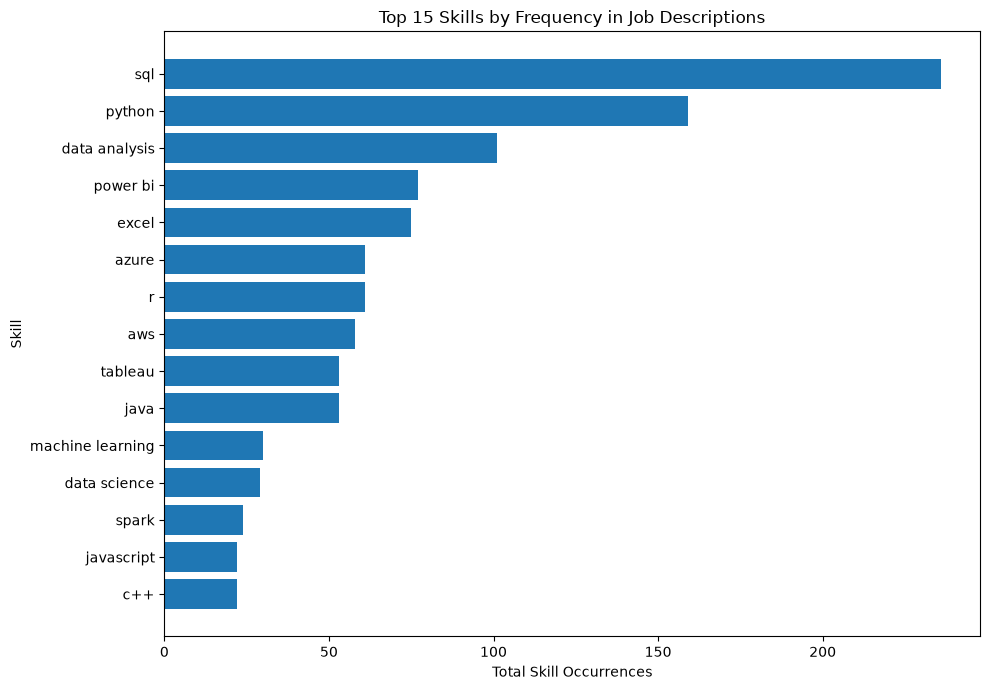

In [34]:
# Visualize the top 15 skills by frequency

top_skills = skill_frequency_df.head(15).sort_values(
    "frequency",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_skills["skill"],
    top_skills["frequency"]
)

plt.xlabel("Total Skill Occurrences")
plt.ylabel("Skill")
plt.title("Top 15 Skills by Frequency in Job Descriptions")

plt.tight_layout()
plt.show()

### Skill Frequency Analysis — Interpretation

The keyword-frequency analysis shows that SQL and Python occur most frequently within the selected skill vocabulary. Data Analysis, Power BI, Excel, Azure, AWS and Tableau also appear frequently across the collected job descriptions.

These results indicate that data, programming and cloud-related skills are prominent within the selected job-posting dataset. However, the frequencies represent occurrences of the predefined skill vocabulary rather than unique job postings, so they should be interpreted as text-based skill frequency rather than direct measures of overall market demand.

The analysis also depends on the initial skill vocabulary and therefore represents a controlled keyword-based EDA approach.

In [36]:
# Calculate the number of unique job postings containing each skill

skill_posting_count = {}

for skill in skill_keywords:
    pattern = r"(?<!\w)" + re.escape(skill.lower()) + r"(?!\w)"

    skill_posting_count[skill] = text_df["description_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    ).sum()

skill_posting_df = pd.DataFrame(
    skill_posting_count.items(),
    columns=["skill", "job_postings"]
).sort_values(
    "job_postings",
    ascending=False
).reset_index(drop=True)

print("Top 15 skills by number of job postings:")
print(skill_posting_df.head(15))

Top 15 skills by number of job postings:
               skill  job_postings
0                sql           180
1             python           125
2      data analysis            85
3              excel            67
4                  r            58
5           power bi            57
6            tableau            43
7               java            39
8                aws            38
9              azure            36
10      data science            28
11  machine learning            27
12               c++            19
13        javascript            18
14                c#            17


In [37]:
# Inspect examples where the skill "R" was detected

r_pattern = r"(?<!\w)" + re.escape("r") + r"(?!\w)"

r_matches = text_df[
    text_df["description_clean"].str.contains(
        r_pattern,
        regex=True,
        na=False
    )
]

print("Job postings containing the keyword 'r':", len(r_matches))

for i, text in enumerate(r_matches["description_clean"].head(5)):
    print(f"\n--- Example {i + 1} ---")
    print(text[:1000])

Job postings containing the keyword 'r': 58

--- Example 1 ---
this job is with moody's, an inclusive employer and a member of mygwork – the largest global platform for the lgbtq business community. please do not contact the recruiter directly. skills and competencies 10 years of software engineering experience delivering complex, large-scale, multi-team initiatives with measurable business impact strong expertise in java, scala, c#, c++, or python, with extensive experience building scalable apis, microservices, and distributed systems deep knowledge of r…

--- Example 2 ---
this job is with abb, an inclusive employer and a member of mygwork – the largest global platform for the lgbtq business community. please do not contact the recruiter directly. at abb, we help industries run leaner and cleaner—and every person here makes that happen. you’ll be empowered to lead, supported to grow, and proud of the impact we create together. join us and help run what runs the world. this position 

In [38]:
# Remove ambiguous standalone "R" from the skill vocabulary

skill_keywords_clean = [
    skill for skill in skill_keywords
    if skill != "r"
]

print("Original skill vocabulary:", len(skill_keywords))
print("Cleaned skill vocabulary:", len(skill_keywords_clean))
print("Removed ambiguous skill:", "r")

Original skill vocabulary: 36
Cleaned skill vocabulary: 35
Removed ambiguous skill: r


In [39]:
# Recalculate skill coverage using the cleaned vocabulary

skill_posting_count = {}

for skill in skill_keywords_clean:
    pattern = r"(?<!\w)" + re.escape(skill.lower()) + r"(?!\w)"

    skill_posting_count[skill] = text_df["description_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    ).sum()

skill_posting_df = pd.DataFrame(
    skill_posting_count.items(),
    columns=["skill", "job_postings"]
).sort_values(
    "job_postings",
    ascending=False
).reset_index(drop=True)

print("Top 15 skills by number of job postings:")
print(skill_posting_df.head(15))

Top 15 skills by number of job postings:
               skill  job_postings
0                sql           180
1             python           125
2      data analysis            85
3              excel            67
4           power bi            57
5            tableau            43
6               java            39
7                aws            38
8              azure            36
9       data science            28
10  machine learning            27
11               c++            19
12        javascript            18
13                c#            17
14             spark            17


In [40]:
# Recalculate total skill frequency using the cleaned vocabulary

skill_frequency = Counter()

for text in text_df["description_clean"]:
    counts = count_skills(text, skill_keywords_clean)

    for skill, count in counts.items():
        skill_frequency[skill] += count

skill_frequency_df = pd.DataFrame(
    skill_frequency.items(),
    columns=["skill", "frequency"]
).sort_values(
    "frequency",
    ascending=False
).reset_index(drop=True)

print("Top 15 skills by total frequency:")
print(skill_frequency_df.head(15))

Top 15 skills by total frequency:
               skill  frequency
0                sql        236
1             python        159
2      data analysis        101
3           power bi         77
4              excel         75
5              azure         61
6                aws         58
7               java         53
8            tableau         53
9   machine learning         30
10      data science         29
11             spark         24
12               c++         22
13        javascript         22
14                c#         20


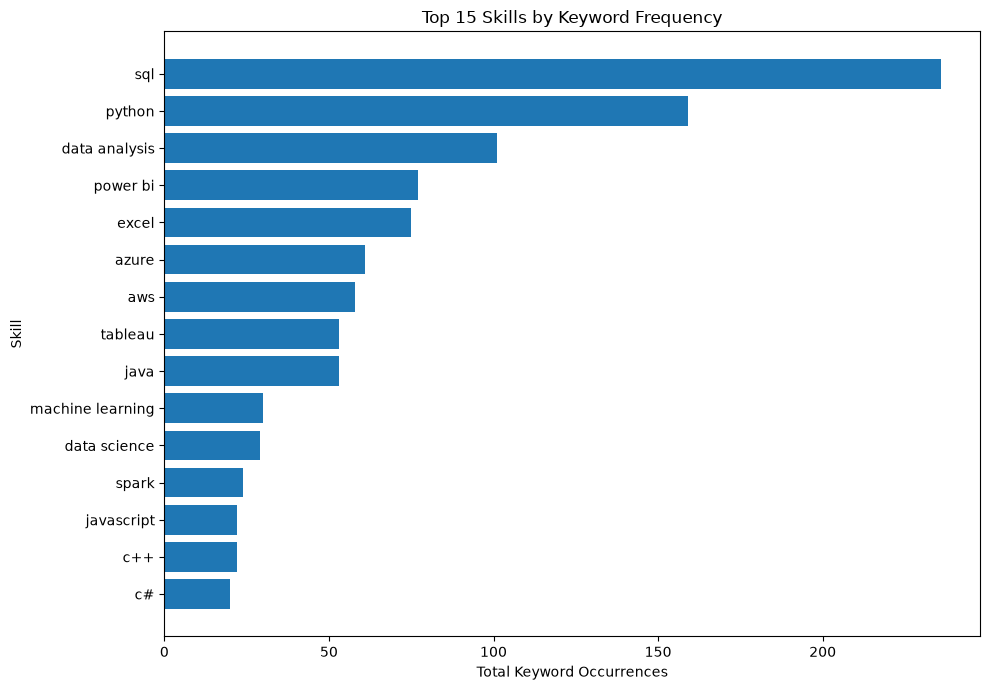

In [41]:
# Visualize top 15 skills using the cleaned vocabulary

top_skills = skill_frequency_df.head(15).sort_values(
    "frequency",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_skills["skill"],
    top_skills["frequency"]
)

plt.xlabel("Total Keyword Occurrences")
plt.ylabel("Skill")
plt.title("Top 15 Skills by Keyword Frequency")

plt.tight_layout()
plt.show()

### Skill Frequency Analysis — Interpretation

SQL and Python have the highest keyword frequencies within the predefined skill vocabulary, followed by Data Analysis, Power BI and Excel. Cloud technologies such as Azure and AWS, along with Tableau, Java, Machine Learning and Data Science, also occur frequently.

The analysis uses two measures: total keyword frequency and the number of unique job postings containing each skill. Total frequency captures repeated mentions, while posting coverage indicates how widely a skill appears across different postings.

A standalone "R" keyword was excluded because contextual inspection showed that several matches referred to terms such as "R&D" rather than the R programming language. This demonstrates the need for validation when using rule-based skill extraction.

In [42]:
# Create a skill-presence matrix for each job posting

skill_presence_df = pd.DataFrame(index=text_df.index)

for skill in skill_keywords_clean:
    pattern = r"(?<!\w)" + re.escape(skill.lower()) + r"(?!\w)"
    
    skill_presence_df[skill] = text_df["description_clean"].str.contains(
        pattern,
        regex=True,
        na=False
    )

print("Skill presence matrix shape:", skill_presence_df.shape)
display(skill_presence_df.head())

Skill presence matrix shape: (2500, 35)


,python,java,javascript,typescript,c++,c#,sql,html,css,react,...,data analysis,power bi,tableau,excel,tensorflow,pytorch,spark,hadoop,snowflake,linux
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [43]:
# Calculate skill coverage within each job category

category_sizes = text_df["category_name"].value_counts()

category_skill_counts = skill_presence_df.groupby(
    text_df["category_name"]
).sum()

category_skill_pct = category_skill_counts.div(
    category_sizes,
    axis=0
) * 100

print("Category-wise skill coverage calculated.")
display(category_skill_pct.round(2))

Category-wise skill coverage calculated.


,python,java,javascript,typescript,c++,c#,sql,html,css,react,...,data analysis,power bi,tableau,excel,tensorflow,pytorch,spark,hadoop,snowflake,linux
category_name,,,,,,,,,,,,,,,,,,,,,
Accounting & Finance Jobs,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.39,1.39,0.00,1.39,0.0,0.0,0.00,0.00,0.00,0.00
Admin Jobs,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,11.11,0.0,0.0,0.00,0.00,0.00,0.00
Consultancy Jobs,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00
Creative & Design Jobs,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,2.70,0.0,0.0,0.00,0.00,0.00,0.00
Customer Services Jobs,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00
"Energy, Oil & Gas Jobs",0.00,0.00,0.00,0.00,0.00,0.00,14.29,0.00,0.00,0.00,...,0.00,14.29,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00
Engineering Jobs,2.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,2.33,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00
Graduate Jobs,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.00
HR & Recruitment Jobs,8.33,0.00,0.00,0.00,0.00,0.00,8.33,0.00,0.00,0.00,...,8.33,0.00,0.00,16.67,0.0,0.0,0.00,0.00,0.00,0.00


In [44]:
# Select categories with at least 10 job postings
# to reduce instability from very small category samples

reliable_categories = category_sizes[category_sizes >= 10].index

category_skill_pct_reliable = category_skill_pct.loc[reliable_categories]

print("Categories included:", len(reliable_categories))
print("\nCategory sizes:")
display(category_sizes.loc[reliable_categories])

Categories included: 9

Category sizes:


category_name
IT Jobs                             1713
PR, Advertising & Marketing Jobs     494
Accounting & Finance Jobs             72
Sales Jobs                            70
Engineering Jobs                      43
Creative & Design Jobs                37
Consultancy Jobs                      16
HR & Recruitment Jobs                 12
Teaching Jobs                         10
Name: count, dtype: int64

In [45]:
# Identify the top 10 skills by posting coverage for each reliable category

top_skills_by_category = {}

for category in category_skill_pct_reliable.index:
    top_skills = (
        category_skill_pct_reliable.loc[category]
        .sort_values(ascending=False)
        .head(10)
    )
    
    top_skills_by_category[category] = top_skills

# Convert results into a readable table
top_skills_category_df = pd.concat(
    top_skills_by_category,
    names=["category_name", "skill"]
).reset_index(name="coverage_percentage")

top_skills_category_df["coverage_percentage"] = (
    top_skills_category_df["coverage_percentage"].round(2)
)

display(top_skills_category_df)

,category_name,skill,coverage_percentage
0,IT Jobs,sql,10.27
1,IT Jobs,python,7.12
2,IT Jobs,data analysis,4.55
3,IT Jobs,power bi,3.15
4,IT Jobs,excel,3.15
...,...,...,...
85,Teaching Jobs,machine learning,0.00
86,Teaching Jobs,deep learning,0.00
87,Teaching Jobs,data science,0.00
88,Teaching Jobs,tableau,0.00


In [46]:
# Identify the top skills with non-zero coverage for each reliable category

top_skills_by_category = {}

for category in category_skill_pct_reliable.index:
    top_skills = (
        category_skill_pct_reliable.loc[category]
        .loc[lambda x: x > 0]
        .sort_values(ascending=False)
        .head(10)
    )
    
    top_skills_by_category[category] = top_skills

# Convert results into a readable table
top_skills_category_df = pd.concat(
    top_skills_by_category,
    names=["category_name", "skill"]
).reset_index(name="coverage_percentage")

top_skills_category_df["coverage_percentage"] = (
    top_skills_category_df["coverage_percentage"].round(2)
)

display(top_skills_category_df)

,category_name,skill,coverage_percentage
0,IT Jobs,sql,10.27
1,IT Jobs,python,7.12
2,IT Jobs,data analysis,4.55
3,IT Jobs,excel,3.15
4,IT Jobs,power bi,3.15
5,IT Jobs,tableau,2.45
6,IT Jobs,aws,2.22
7,IT Jobs,java,2.22
8,IT Jobs,azure,2.10
9,IT Jobs,machine learning,1.46


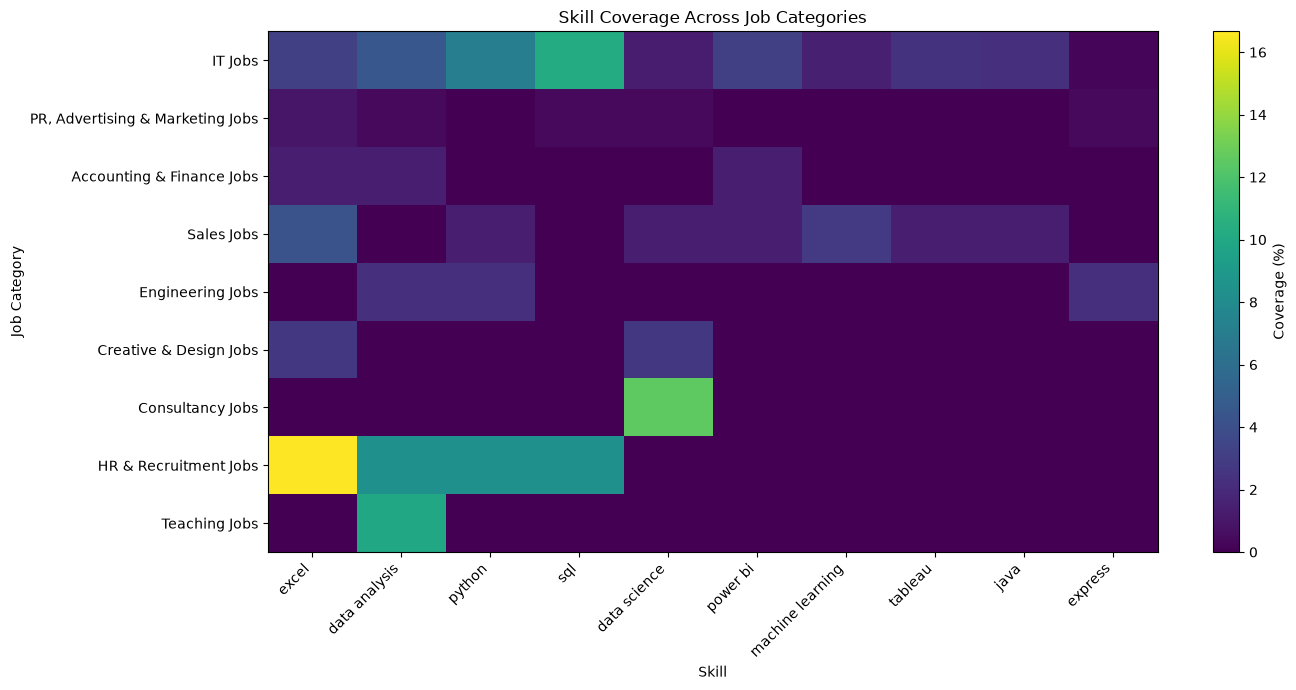

In [47]:
# Visualize top skills across reliable job categories

# Select the 10 most frequently covered skills across the reliable categories
global_top_skills = (
    category_skill_pct_reliable.mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

heatmap_data = category_skill_pct_reliable[
    global_top_skills
]

plt.figure(figsize=(14, 7))

plt.imshow(
    heatmap_data.values,
    aspect="auto"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xlabel("Skill")
plt.ylabel("Job Category")
plt.title("Skill Coverage Across Job Categories")

plt.colorbar(label="Coverage (%)")

plt.tight_layout()
plt.show()

### Top Skills by Category — Interpretation

The category-wise analysis compares the percentage of job postings mentioning each skill within the selected job categories. This percentage-based approach reduces the effect of differences in category size.

IT Jobs show the strongest coverage across the selected technical skills, with SQL and Python appearing most frequently among the predefined vocabulary. Data Analysis, Excel, Power BI, Tableau, AWS, Java, Azure and Machine Learning also appear across IT postings.

Other categories show different skill patterns. For example, Excel and Data Analysis appear in several non-IT categories, while Engineering postings show coverage for Python, Node.js, Express, MongoDB and PostgreSQL.

Categories with smaller sample sizes, such as HR & Recruitment and Teaching, should be interpreted cautiously because a small number of postings can produce relatively large percentage changes.

The analysis is based on the predefined 35-skill vocabulary and therefore represents coverage of the selected skills rather than a complete measure of all skills required in the job market.

In [48]:
from wordcloud import WordCloud

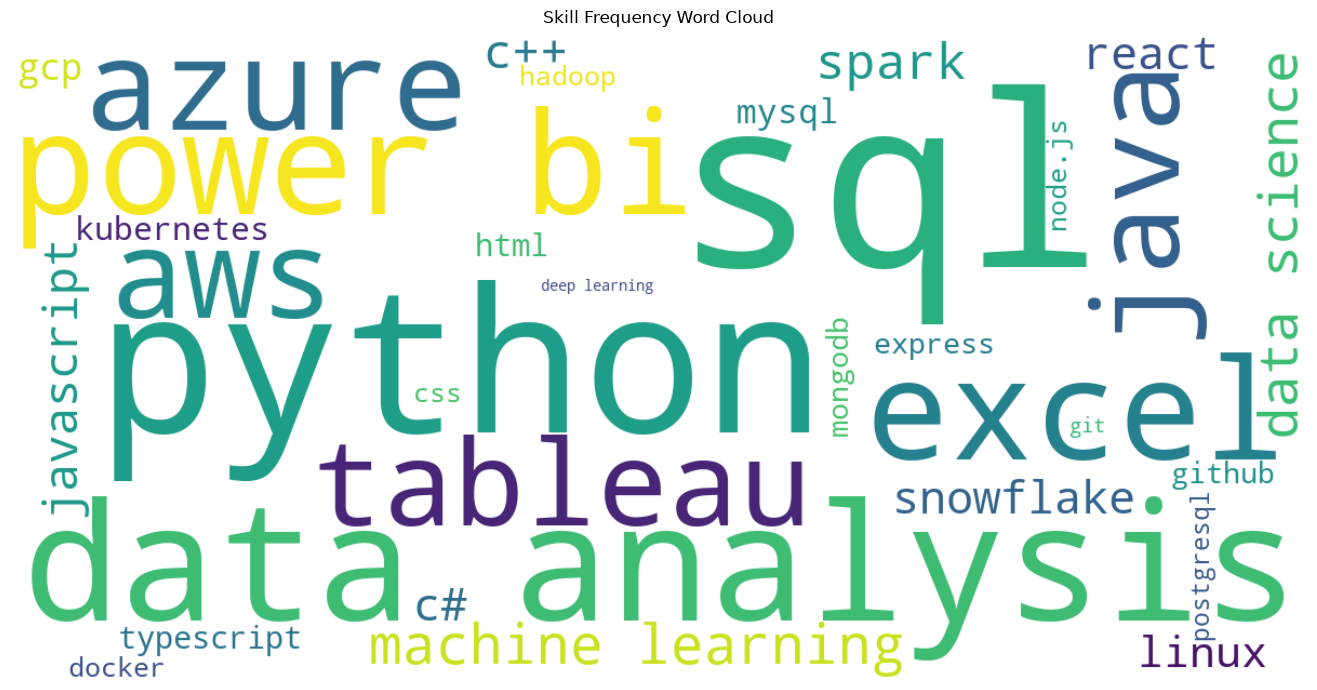

In [49]:
# Create a word cloud from validated skill frequencies

skill_freq_dict = dict(
    zip(
        skill_frequency_df["skill"],
        skill_frequency_df["frequency"]
    )
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate_from_frequencies(skill_freq_dict)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Skill Frequency Word Cloud")
plt.tight_layout()
plt.show()

### Skill Frequency Word Cloud — Interpretation

The word cloud provides a visual representation of the frequency of the predefined skills identified across the 2,500 job postings. Larger terms represent skills with higher keyword frequency, while smaller terms represent skills that occurred less frequently.

SQL and Python appear prominently, followed by skills such as Data Analysis, Power BI, Excel, Azure, AWS and Tableau. Other technical skills, including JavaScript, Java, Spark, React, Kubernetes and Snowflake, appear at smaller sizes based on their observed frequencies.

The word cloud is intended as a visual summary of the skill-frequency analysis rather than an independent measure of market demand. Its results are limited to the predefined 35-skill vocabulary and the collected Adzuna job postings.

In [50]:
    # Prepare final text-cleaned dataset for downstream analysis

final_text_columns = [
    "job_id",
    "title",
    "category_name",
    "description_original",
    "description_clean",
    "description_nostopwords",
    "description_lemmatized",
    "description_word_count"
]

postings_text = text_df[final_text_columns].copy()

# Create cleaned-data directory
output_dir = Path("../data/cleaned")
output_dir.mkdir(parents=True, exist_ok=True)

# Save final text dataset
output_path = output_dir / "postings_text.csv"
postings_text.to_csv(output_path, index=False)

print("Final text dataset saved to:", output_path)
print("Dataset shape:", postings_text.shape)

display(postings_text.head())

Final text dataset saved to: ../data/cleaned/postings_text.csv
Dataset shape: (2500, 8)


,job_id,title,category_name,description_original,description_clean,description_nostopwords,description_lemmatized,description_word_count
0,5871227803,Software Engineer,IT Jobs,"This job is with ABB, an inclusive employer an...","this job is with abb, an inclusive employer an...","job abb, inclusive employer member mygwork – l...","this job be with abb , an inclusive employer a...",85
1,5897683093,Software Engineer,IT Jobs,"This job is with Kyndryl, an inclusive employe...","this job is with kyndryl, an inclusive employe...","job kyndryl, inclusive employer member mygwork...","this job be with kyndryl , an inclusive employ...",78
2,5890717561,Software Engineer,Engineering Jobs,"This job is with Kyndryl, an inclusive employe...","this job is with kyndryl, an inclusive employe...","job kyndryl, inclusive employer member mygwork...","this job be with kyndryl , an inclusive employ...",78
3,5846723066,Software Engineer,IT Jobs,"This job is with Morningstar, an inclusive emp...","this job is with morningstar, an inclusive emp...","job morningstar, inclusive employer member myg...","this job be with morningstar , an inclusive em...",78
4,5893930080,System Software Engineer,IT Jobs,System Software Engineer Role Overview We're l...,system software engineer role overview we're l...,system software engineer role overview looking...,system software engineer role overview we be l...,69
